
# Modeling and Dashboard Preparation

## Objective

In this notebook, I build and evaluate machine learning models using the full feature dataset, and prepare the results for visualization in the wildfire risk dashboard.

The goal is to identify high-risk locations and evaluate how well the models can prioritize wildfire-prone areas.


In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score



## Step 1: Load Final Dataset

I load the final dataset containing:

- Climate variables
- Temporal features (lags and rolling values)
- Vegetation (fuel presence)
- Human interaction (distance to roads)
- Fire occurrence labels

This dataset represents the full feature space used for modeling.


In [10]:

df = pd.read_parquet(
    "~/Downloads/df_sample_with_spatial_features.parquet"
)

print(df.shape)
df.head()


(2000000, 16)


,year,day,lat,lon,fire,pr,tmmx,tmmn,pr_lag1,pr_lag3,pr_lag7,pr_roll7,pr_roll14,doy,distance_to_road_km,fuel_present
0,2022,2022-04-29,40.775000,-104.766667,0,0.0,15.649994,3.050018,0.0,0.0,0.0,0.0,0.0,119,30.139745,1
1,2023,2023-06-27,37.150000,-107.308333,0,0.0,30.950012,11.350006,0.5,0.0,0.0,0.5,2.7,178,232.598649,1
2,2020,2020-05-06,40.983333,-106.891667,0,0.0,15.250000,-3.750000,0.4,13.2,1.6,31.6,50.6,127,130.720860,0
3,2018,2018-06-19,40.358333,-106.475000,0,0.0,19.250000,2.950012,0.0,6.0,0.0,15.8,15.8,170,64.914936,1
4,2023,2023-10-15,37.108333,-106.600000,0,0.0,13.450012,-2.649994,0.0,0.0,0.0,0.0,32.1,288,163.869051,1


In [11]:
df["fire"].value_counts(normalize=True)

fire
0    0.999901
1    0.000099
Name: proportion, dtype: float64

In [12]:
df[["fuel_present", "distance_to_road_km"]].describe()

,fuel_present,distance_to_road_km
count,2.000000e+06,2.000000e+06
mean,7.375360e-01,7.243403e+01
std,4.399736e-01,5.730673e+01
min,0.000000e+00,9.722438e-03
25%,0.000000e+00,2.589810e+01
50%,1.000000e+00,5.765176e+01
75%,1.000000e+00,1.123524e+02
max,1.000000e+00,2.346130e+02


In [13]:
df["fuel_present"].value_counts(normalize=True)

fuel_present
1    0.737536
0    0.262464
Name: proportion, dtype: float64

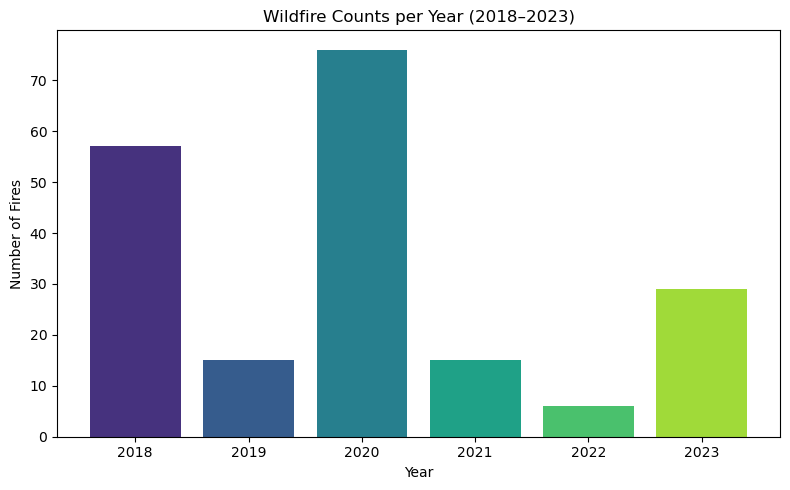

In [14]:
fires_per_year = df.groupby("year")["fire"].sum()

plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", len(fires_per_year))

plt.bar(
    fires_per_year.index.astype(str),
    fires_per_year.values,
    color=colors
)

plt.title("Wildfire Counts per Year (2018–2023)")
plt.xlabel("Year")
plt.ylabel("Number of Fires")
plt.tight_layout()
plt.show()

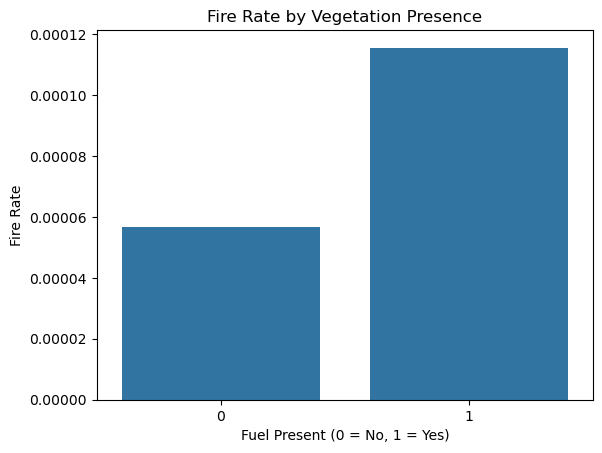

In [16]:
sns.barplot(
    x="fuel_present",
    y="fire",
    data=df.sample(200_000),
    errorbar=None
)

plt.title("Fire Rate by Vegetation Presence")
plt.xlabel("Fuel Present (0 = No, 1 = Yes)")
plt.ylabel("Fire Rate")
plt.show()

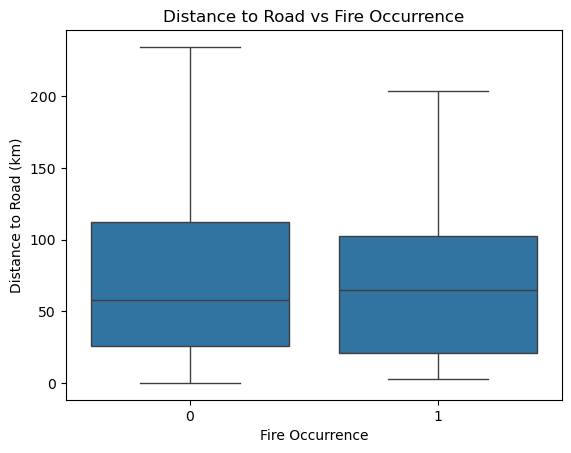

In [17]:
sns.boxplot(
    x="fire",
    y="distance_to_road_km",
    data=df.sample(200_000)
)

plt.title("Distance to Road vs Fire Occurrence")
plt.xlabel("Fire Occurrence")
plt.ylabel("Distance to Road (km)")
plt.show()


## Step 2: Define Input Features

The model uses climate, temporal, and spatial variables to predict wildfire risk.
``


In [18]:

features = [
    "pr", "tmmx", "tmmn",
    "pr_lag1", "pr_lag3", "pr_lag7",
    "pr_roll7", "pr_roll14",
    "doy",
    "distance_to_road_km",
    "fuel_present"
]


## Step 3: Train/Test Split

- Train: 2018–2022  
- Test: 2023  

This ensures evaluation on unseen data.


In [19]:

train_df = df[df["year"] <= 2022]
test_df  = df[df["year"] == 2023]

print(train_df.shape, test_df.shape)
print("Train fire rate:", train_df["fire"].mean())


(1665129, 16) (334871, 16)
Train fire rate: 0.00010149363803044689



## Step 4: Sampling Strategy

A subset of training data is used to reduce computational cost while maintaining class balance.


In [20]:

train_sample = train_df.sample(frac=0.10, random_state=42)

X_train = train_sample[features]
y_train = train_sample["fire"]

X_test = test_df[features]
y_test = test_df["fire"]



## Step 5: Model Evaluation

Models are evaluated using:

- ROC-AUC (ranking ability)
- PR-AUC (important for rare events)
``


In [21]:

logit = LogisticRegression(
    max_iter=200,
    class_weight="balanced",
    n_jobs=-1
)

logit.fit(X_train, y_train)

logit_probs = logit.predict_proba(X_test)[:, 1]

print("Logistic ROC-AUC:", roc_auc_score(y_test, logit_probs))
print("Logistic PR-AUC :", average_precision_score(y_test, logit_probs))


/Users/malikibrahimalikhan/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic ROC-AUC: 0.7083731101997874
Logistic PR-AUC : 0.00019128439902074777


In [22]:
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)

gbm_probs = gbm.predict_proba(X_test)[:, 1]

gbm_roc = roc_auc_score(y_test, gbm_probs)
gbm_pr  = average_precision_score(y_test, gbm_probs)

print("GBM ROC-AUC:", gbm_roc)
print("GBM PR-AUC :", gbm_pr)

GBM ROC-AUC: 0.7060702742147661
GBM PR-AUC : 0.00018123817787525244


In [23]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]

print("RF ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("RF PR-AUC :", average_precision_score(y_test, rf_probs))

RF ROC-AUC: 0.6693423496290274
RF PR-AUC : 0.00032019077961598644


In [51]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# -----------------------------
# XGBoost model (baseline)
# -----------------------------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)

# Predict on test set
xgb_probs = xgb.predict_proba(X_test)[:, 1]

# Evaluate
xgb_roc = roc_auc_score(y_test, xgb_probs)
xgb_pr  = average_precision_score(y_test, xgb_probs)

print("XGBoost ROC-AUC:", xgb_roc)
print("XGBoost PR-AUC :", xgb_pr)

XGBoost ROC-AUC: 0.7113022837945802
XGBoost PR-AUC : 0.0005014162893565477


In [55]:
# -----------------------------
# Model performance summary
# -----------------------------
model_perf = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, logit_probs),
        gbm_roc,
        roc_auc_score(y_test, rf_probs),
        xgb_roc
    ]
})

model_perf


,Model,ROC_AUC
0,Logistic Regression,0.708373
1,Gradient Boosting,0.706070
2,Random Forest,0.669342
3,XGBoost,0.711302


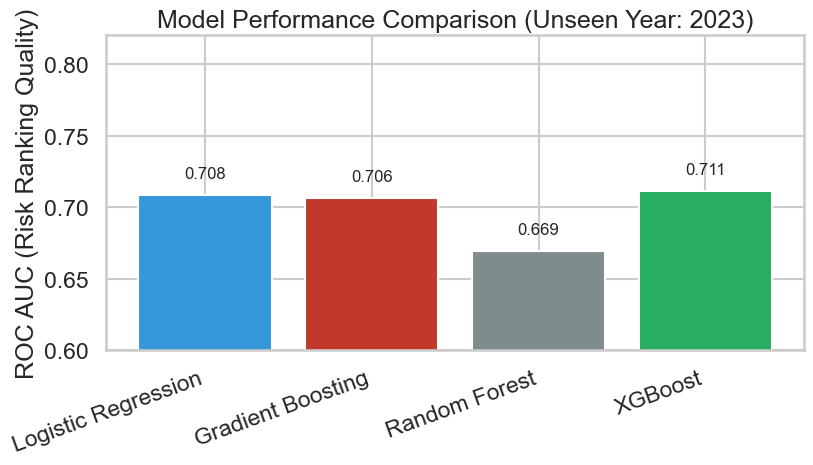

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(9, 5))  # slightly wider

colors = [
    "#3498DB",  # Logistic Regression
    "#C0392B",  # Gradient Boosting
    "#7f8c8d",  # Random Forest
    "#27AE60"   # XGBoost
]

bars = plt.bar(
    model_perf["Model"],
    model_perf["ROC_AUC"],
    color=colors
)

# Annotate values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.ylabel("ROC AUC (Risk Ranking Quality)")
plt.title("Model Performance Comparison (Unseen Year: 2023)")
plt.ylim(0.6, 0.82)

plt.xticks(rotation=20, ha="right")

plt.subplots_adjust(bottom=0.25)

plt.show()

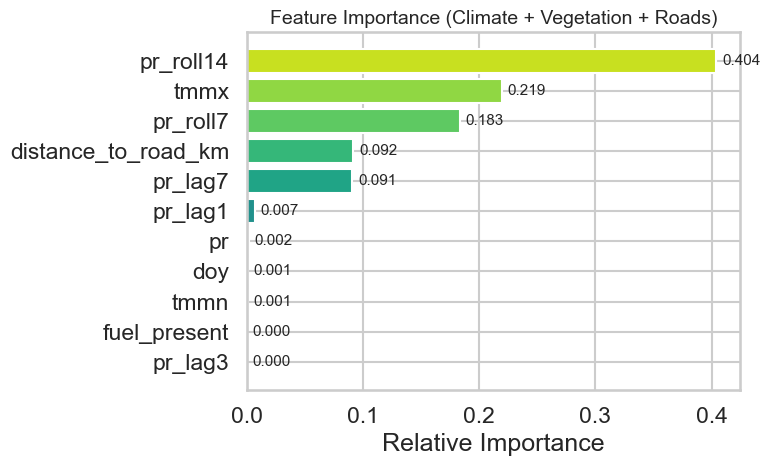

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.Series(
    gbm.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))

colors = sns.color_palette("viridis", len(importance))

bars = plt.barh(
    importance.index,
    importance.values,
    color=colors
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=11
    )

plt.title("Feature Importance (Climate + Vegetation + Roads)", fontsize=14)
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


## Step 6: Risk-Based Evaluation

Instead of classification accuracy, the model is evaluated based on its ability to rank high-risk areas.

Top risk percentiles are used:
- Top 5%
- Top 10%
- Top 20%


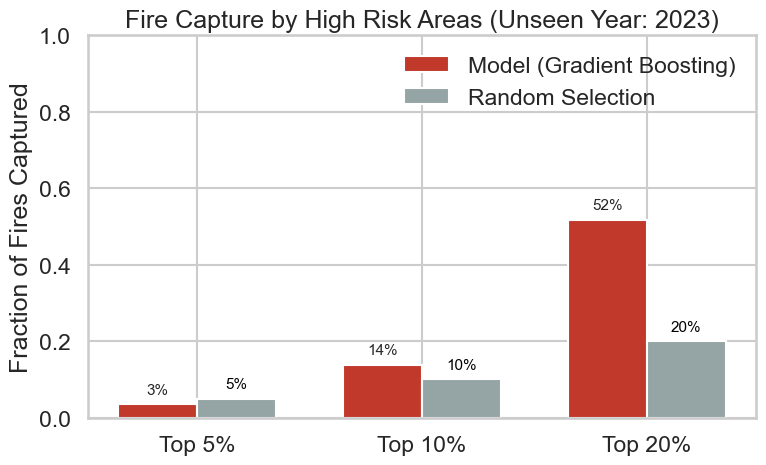

In [53]:
viz_df = test_df.copy()
viz_df["risk"] = gbm_probs
viz_df = viz_df.sort_values("risk", ascending=False)

total_fires = viz_df["fire"].sum()

thresholds = [0.05, 0.10, 0.20]
labels = ["Top 5%", "Top 10%", "Top 20%"]

random_capture = thresholds

model_capture = []
for t in thresholds:
    top_n = int(len(viz_df) * t)
    captured = viz_df.iloc[:top_n]["fire"].sum() / total_fires
    model_capture.append(captured)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

# Model capture bars
bars_model = plt.bar(
    x - width/2,
    model_capture,
    width,
    label="Model (Gradient Boosting)",
    color="#C0392B"
)

# Random baseline bars
bars_random = plt.bar(
    x + width/2,
    random_capture,
    width,
    label="Random Selection",
    color="#95A5A6"
)

plt.xticks(x, labels)
plt.ylabel("Fraction of Fires Captured")
plt.title("Fire Capture by High Risk Areas (Unseen Year: 2023)")
plt.ylim(0, 1)
plt.legend(frameon=False)

# Annotate model bars
for bar in bars_model:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.0%}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Annotate random bars
for bar in bars_random:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.0%}",
        ha="center",
        va="bottom",
        fontsize=11,
        color="black"
    )

plt.tight_layout()
plt.show()

/var/folders/b_/lqk5v6r95zs00836sfhn9pxw0000gn/T/ipykernel_67882/3064912581.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  counties["area"] = counties.geometry.area


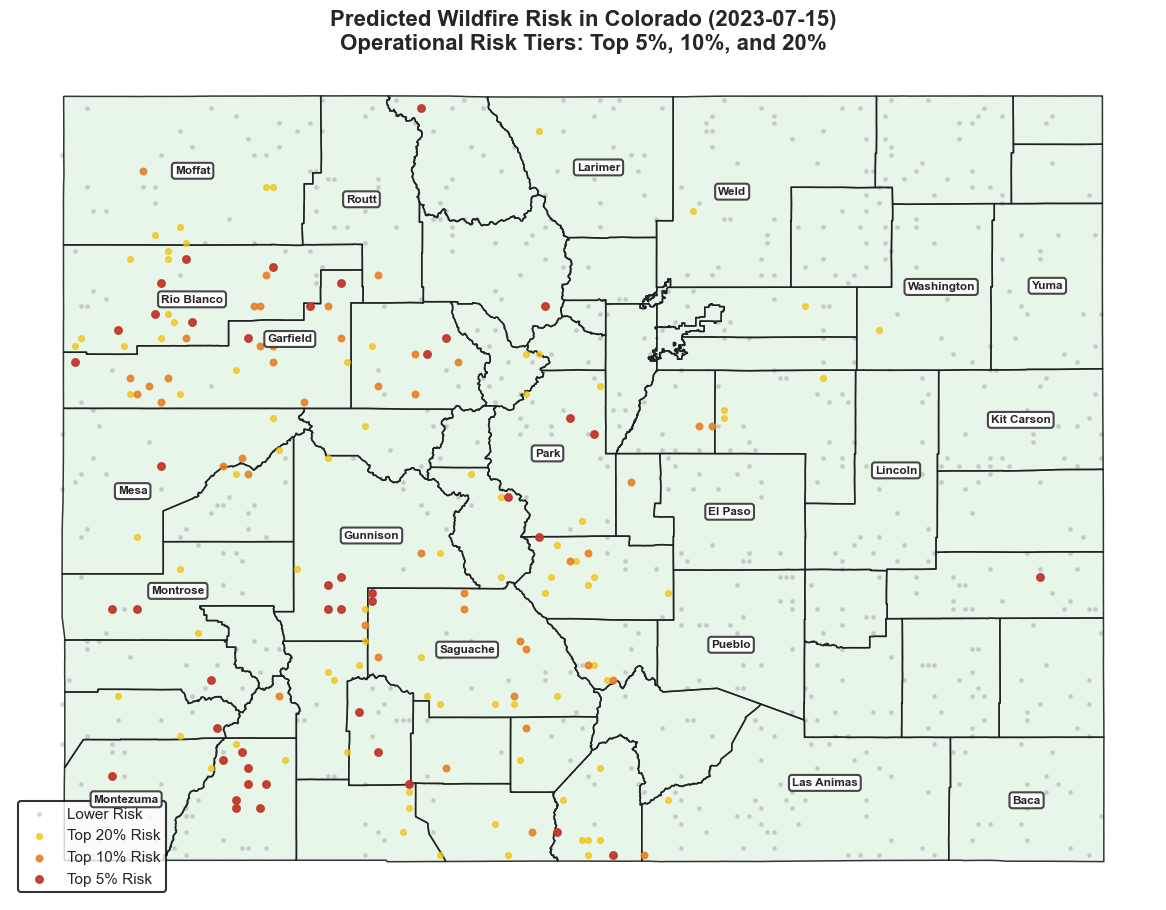

In [62]:
# ---------------------------------------
# Select a specific day
# ---------------------------------------
target_day = "2023-07-15"

day_df = test_df[test_df["day"] == target_day].copy()
day_probs = gbm_probs[test_df["day"] == target_day]
day_df["risk"] = day_probs

# ---------------------------------------
# Convert to GeoDataFrame FIRST
# ---------------------------------------
import geopandas as gpd
from shapely.geometry import Point

day_gdf = gpd.GeoDataFrame(
    day_df,
    geometry=gpd.points_from_xy(day_df.lon, day_df.lat),
    crs="EPSG:4326"
)

# ---------------------------------------
# NOW create risk tiers (THIS WAS MISSING)
# ---------------------------------------
q95 = day_gdf["risk"].quantile(0.95)
q90 = day_gdf["risk"].quantile(0.90)
q80 = day_gdf["risk"].quantile(0.80)

day_gdf["risk_tier"] = "Lower Risk"
day_gdf.loc[day_gdf["risk"] >= q80, "risk_tier"] = "Top 20%"
day_gdf.loc[day_gdf["risk"] >= q90, "risk_tier"] = "Top 10%"
day_gdf.loc[day_gdf["risk"] >= q95, "risk_tier"] = "Top 5%"

# ---------------------------------------
# Load Colorado counties
# ---------------------------------------
counties = gpd.read_file(
    "/Users/malikibrahimalikhan/Downloads/tl_2023_us_county/tl_2023_us_county.shp"
)
counties = counties[counties["STATEFP"] == "08"].to_crs("EPSG:4326")

# Select counties for labels
counties["area"] = counties.geometry.area
label_counties = counties.sort_values("area", ascending=False).head(20)

# ---------------------------------------
# Plot
# ---------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

# Light green background
colorado = counties.dissolve()
colorado.plot(
    ax=ax,
    color="#e8f5e9",
    edgecolor="none",
    zorder=0
)

# County boundaries
counties.boundary.plot(
    ax=ax,
    color="#1f1f1f",
    linewidth=1.1,
    alpha=0.9,
    zorder=2
)

# Lower risk (gray)
day_gdf[day_gdf["risk_tier"] == "Lower Risk"].plot(
    ax=ax,
    color="#8c8c8c",
    markersize=5,
    alpha=0.25,
    label="Lower Risk",
    zorder=1
)

# Top 20%
day_gdf[day_gdf["risk_tier"] == "Top 20%"].plot(
    ax=ax,
    color="#F1C40F",
    markersize=14,
    alpha=0.7,
    label="Top 20% Risk",
    zorder=3
)

# Top 10%
day_gdf[day_gdf["risk_tier"] == "Top 10%"].plot(
    ax=ax,
    color="#E67E22",
    markersize=18,
    alpha=0.85,
    label="Top 10% Risk",
    zorder=4
)

# Top 5%
day_gdf[day_gdf["risk_tier"] == "Top 5%"].plot(
    ax=ax,
    color="#C0392B",
    markersize=24,
    alpha=0.95,
    label="Top 5% Risk",
    zorder=5
)

# County labels
for _, row in label_counties.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x,
        pt.y,
        row["NAME"],
        fontsize=8.5,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            alpha=0.9,
            edgecolor="#333333",
            boxstyle="round,pad=0.25"
        ),
        zorder=6
    )

ax.set_title(
    f"Predicted Wildfire Risk in Colorado ({target_day})\n"
    "Operational Risk Tiers: Top 5%, 10%, and 20%",
    fontsize=16,
    fontweight="bold"
)

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=11,
    loc="lower left"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


## Step: Prepare Model Output for Dashboard Visualization

In this step, I transform the model predictions into a format suitable for the dashboard.

### 1. Generate Risk Scores

Using the trained Gradient Boosting model, I predict wildfire risk probabilities for each observation:

- Each location receives a probability value between 0 and 1
- Higher values indicate a higher likelihood of wildfire occurrence

---

### 2. Standardize Date Format

The `day` column is converted to a consistent string format:

In [80]:
df_copy = df.copy()

df_copy["risk"] = gbm.predict_proba(df_copy[features])[:, 1]
df_copy["day"] = pd.to_datetime(df_copy["day"]).dt.strftime("%Y-%m-%d")

df_copy = (
    df_copy.groupby("day")
    .apply(lambda x: x.nlargest(100, "risk"))   # top 100 per day
    .reset_index(drop=True)
)

def assign_tier(row):
    if row["risk"] >= df_copy["risk"].quantile(0.95):
        return "Top 5%"
    elif row["risk"] >= df_copy["risk"].quantile(0.90):
        return "Top 10%"
    else:
        return "Top 20%"

df_copy["tier"] = df_copy.apply(assign_tier, axis=1)

df_copy = df_copy[["lat", "lon", "risk", "day", "tier"]]

df_copy.to_csv("dashboard_risk.csv", index=False)

print("✅ Smart dataset ready")

✅ Smart dataset ready



## Conclusion

In this notebook, I trained and evaluated models for wildfire prediction using combined climate, vegetation, and human interaction features.

Key findings:

- Tree-based models perform better than linear models
- Temporal features significantly improve prediction
- The model is most effective at ranking high-risk areas
- Top 5–20% risk regions capture a disproportionate number of fires

These results are used directly in the dashboard to visualize wildfire risk patterns.
    `